Olá, Ana!

Meu nome é Alan e estou feliz em revisar seu projeto hoje!

Quando eu identificar um erro pela primeira vez, apenas o apontarei. A ideia é que você tente identificá-lo e corrigi-lo por conta própria. Ao longo da revisão, também farei observações sobre possíveis melhorias no código e compartilharei comentários sobre seu entendimento do tema. Caso encontre dificuldades para resolver algum ponto, na próxima iteração fornecerei dicas mais específicas e exemplos práticos para ajudá-la. Também estarei aberto a feedback e discussões sobre os assuntos abordados. Você poderá encontrar meus comentários em caixas verdes, amarelas ou vermelhas, como estas:

<div class="alert alert-block alert-success"><b>Comentário: </b> <a class="tocSkip"></a>Sucesso. Tudo está correto.</div>

<div class="alert alert-block alert-warning"><b>Comentário: </b> <a class="tocSkip"></a>Observações. Algumas recomendações.</div>

<div class="alert alert-block alert-danger"><b>Comentário: </b> <a class="tocSkip"></a>O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info"><b>Resposta do aluno    </b><a class="tocSkip"></a></div>

<div class="alert alert-block alert-danger">
<b>Comentário geral do revisor: </b> <a class="tocSkip"></a>

Olá, Ana! Obrigado pelo envio. O projeto está muito bem estruturado: análise de ausentes e duplicados, comparação das médias por grupo de churn, matriz de correlação, dois modelos (Regressão Logística 0,924 e Floresta Aleatória 0,928), importância de variáveis, clusterização e taxa de churn por cluster, com conclusões escritas. Comentei cada etapa.

Há um ponto que impede a aprovação: um erro de digitação na importação faz o notebook não rodar do início ao fim. Na célula de imports, você escreveu 'dendrogra' em vez de 'dendrogram' (faltou o 'm' final) ao importar de scipy.cluster.hierarchy. Por isso o import falha (ImportError) e, mais adiante, a célula do dendrograma quebra (NameError: name 'dendrogram' is not defined), deixando o agrupamento hierárquico sem a visualização. Corrigido o nome da função, o notebook roda por completo e o projeto fica pronto.
</div>

<div class="alert alert-block alert-success">
<b>Comentário geral do revisor (iteração 2): </b> <a class="tocSkip"></a>

Olá, Ana! Obrigado pelo reenvio. O ponto que impedia a aprovação foi corrigido: na célula de importações você ajustou o nome da função para dendrogram (antes estava "dendrogra"), então o import deixa de gerar erro e o agrupamento hierárquico volta a funcionar. Com isso o notebook roda do início ao fim, e como o restante já estava correto (EDA, correlação, os dois modelos com acurácia ~0,92 e a análise de clusters), o projeto está aprovado. Parabéns!
</div>



O objetivo deste projeto é analisar os fatores associados à rotatividade de clientes da rede de academias Model Fitness, desenvolver modelos capazes de prever a probabilidade de churn e identificar grupos de clientes com características semelhantes.

A análise será dividida em quatro etapas principais:

1. Análise exploratória dos dados;
2. Construção de modelos de classificação para prever churn;
3. Segmentação dos clientes utilizando clustering;
4. Formulação de conclusões e recomendações para retenção de clientes.

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

<div class="alert alert-block alert-danger">
<b>Comentário do revisor — Importações: </b> <a class="tocSkip"></a>

Aqui está a origem do problema: na última linha você importa 'dendrogra' de scipy.cluster.hierarchy, mas o nome correto da função é 'dendrogram' (faltou o 'm' no final). Como esse nome não existe, o import gera ImportError e a função não fica disponível. Corrija o nome na importação para o notebook rodar.
</div>

<div class="alert alert-block alert-success">
<b>Comentário do revisor (iteração 2) — Importações: </b> <a class="tocSkip"></a>

Corrigido: agora você importa 'dendrogram' (com o 'm' final) de scipy.cluster.hierarchy, então o ImportError desapareceu e a função fica disponível para a etapa de clusterização.
</div>

In [2]:

gym = pd.read_csv('/datasets/gym_churn_us.csv')

gym.head()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

A análise das informações gerais permite verificar a quantidade de registros, o número de colunas e os tipos de dados presentes no conjunto.

Também é importante observar se as variáveis estão armazenadas nos formatos esperados para as análises posteriores.

In [4]:
gym.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

A verificação de valores ausentes é importante porque dados faltantes podem afetar tanto a análise exploratória quanto o desempenho dos modelos de Machine Learning.

Caso não existam valores ausentes, não será necessário realizar um processo de imputação.

In [5]:
gym.duplicated().sum()

0

Também verificamos a existência de registros duplicados. A presença de duplicatas pode distorcer as estatísticas e influenciar os resultados dos modelos.

Caso o resultado seja zero, podemos concluir que não foram identificadas linhas duplicadas no conjunto de dados.

In [6]:
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


A função `describe()` apresenta estatísticas descritivas das variáveis numéricas, incluindo média, desvio padrão, valores mínimo e máximo e quartis.

Essas informações ajudam a compreender a escala das variáveis e a identificar possíveis valores extremos.

In [7]:
gym.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


In [8]:
gym.groupby('Churn').mean().round(2)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.51,0.87,0.53,0.35,0.9,5.75,0.46,29.98,158.45,5.28,4.71,2.02,2.03
1,0.51,0.77,0.36,0.18,0.9,1.73,0.27,26.99,115.08,1.66,0.99,1.47,1.04


Nesta etapa, comparamos as características médias dos clientes que permaneceram na academia (`Churn = 0`) com as características dos clientes que deixaram a academia (`Churn = 1`).

Essa comparação permite identificar diferenças iniciais entre os dois grupos. Em particular, devemos observar variáveis relacionadas à frequência de visitas, duração do contrato, tempo de relacionamento com a academia e gastos adicionais.

Essas diferenças podem indicar fatores associados à maior ou menor probabilidade de churn.

In [9]:
numeric_columns = [
    'gender',
    'Near_Location',
    'Partner',
    'Promo_friends',
    'Phone',
    'Age',
    'Lifetime',
    'Contract_period',
    'Month_to_end_contract',
    'Group_visits',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month',
    'Avg_additional_charges_total'
]

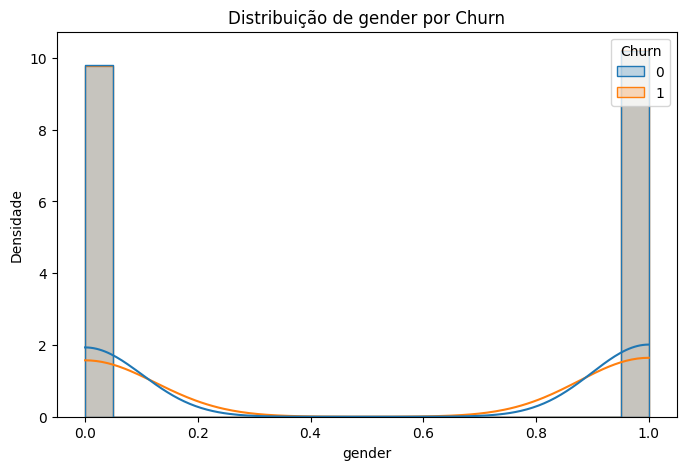

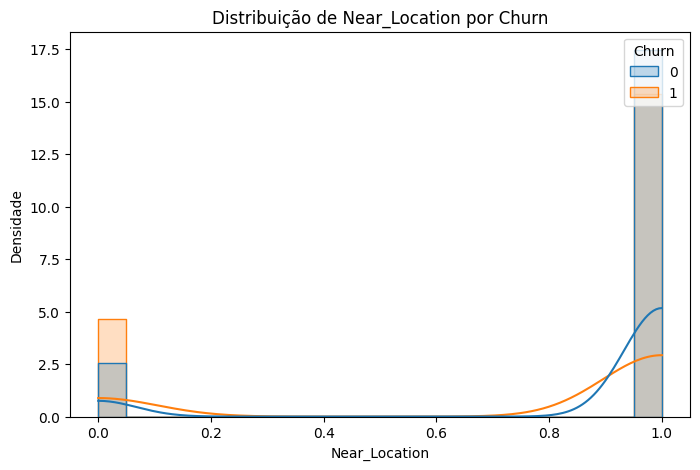

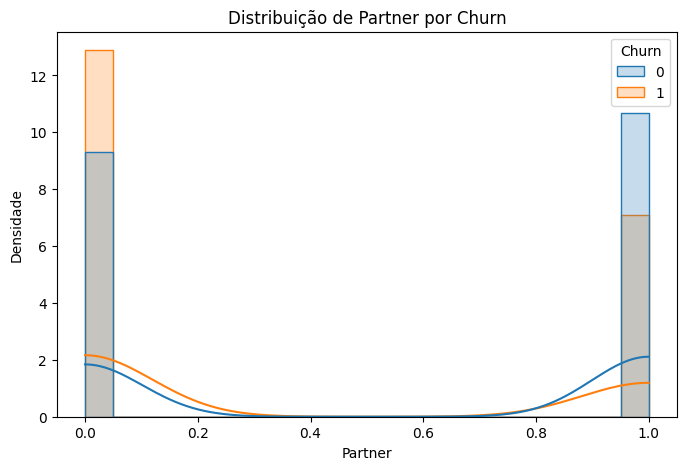

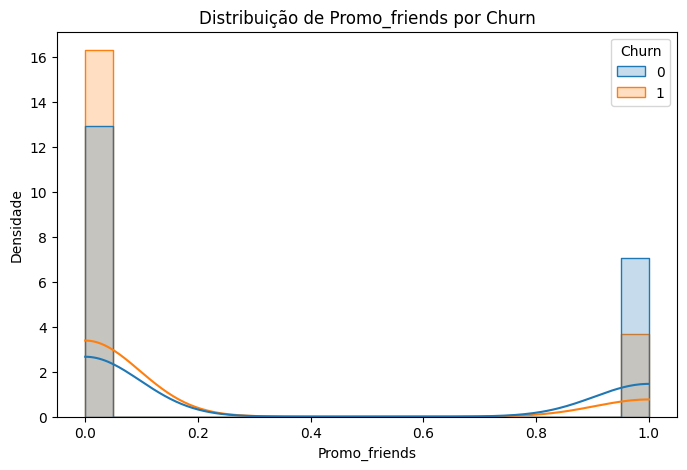

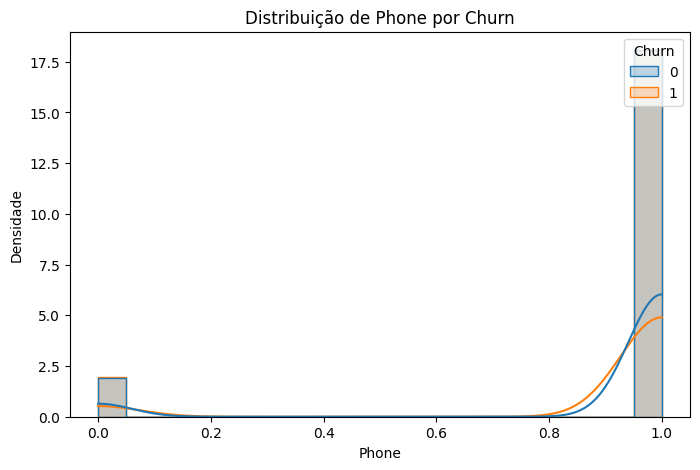

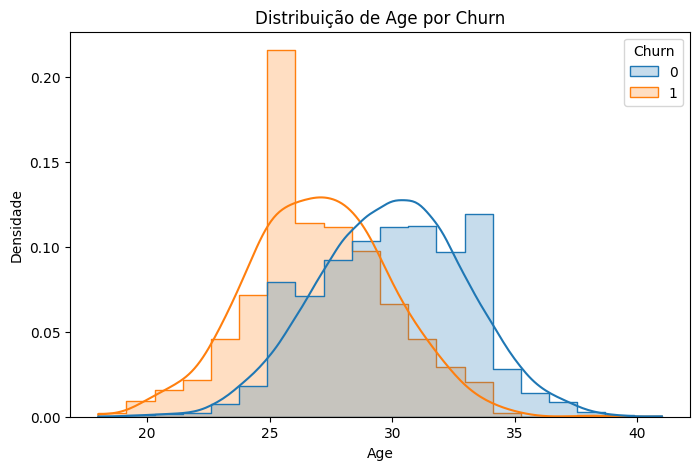

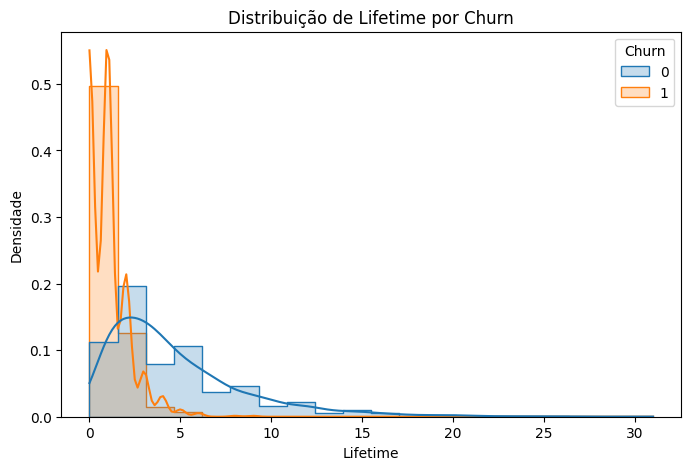

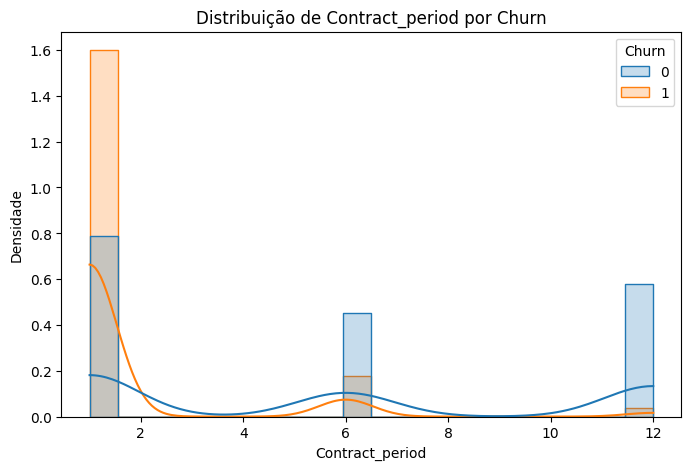

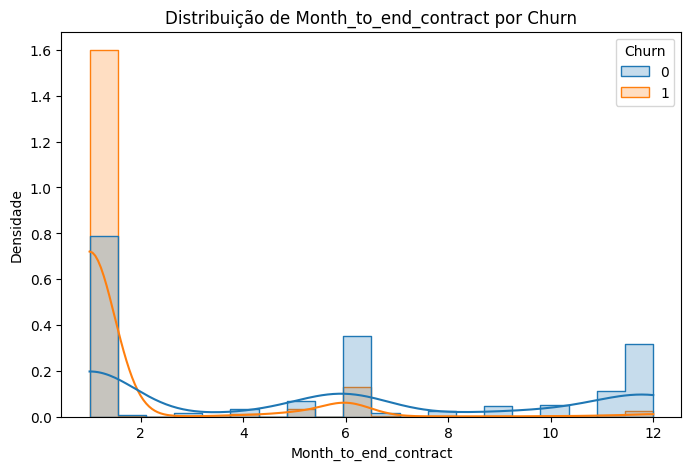

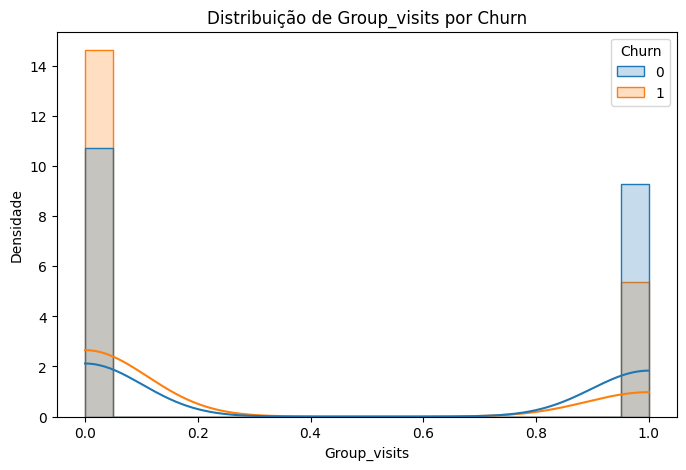

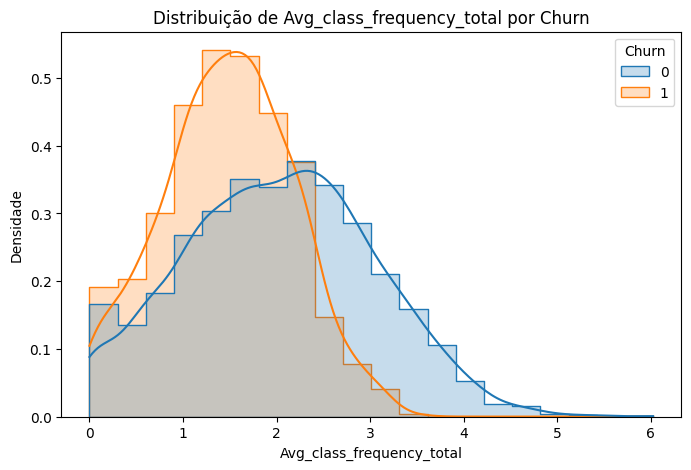

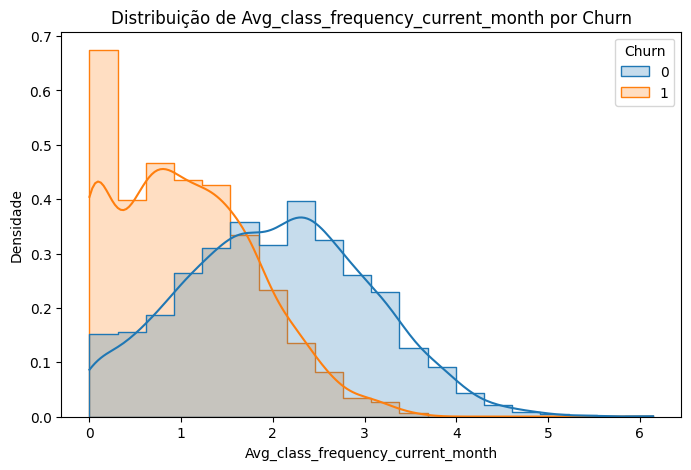

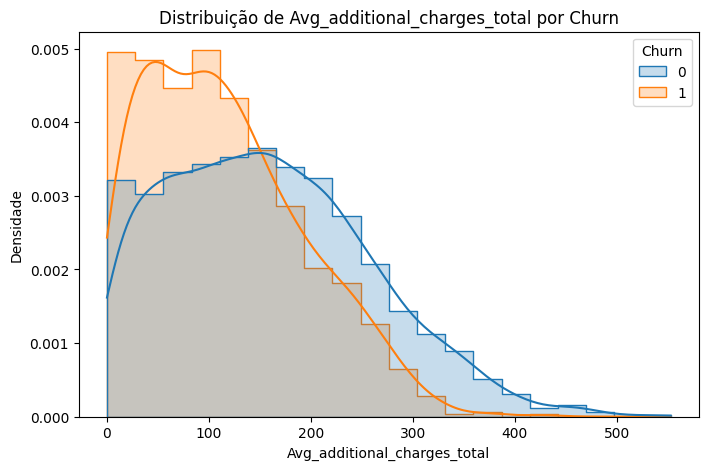

In [10]:
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=gym,
        x=column,
        hue='Churn',
        bins=20,
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )
    
    plt.title(f'Distribuição de {column} por Churn')
    plt.xlabel(column)
    plt.ylabel('Densidade')
    plt.show()

Os histogramas permitem comparar visualmente a distribuição das características entre clientes que permaneceram e clientes que saíram.

As variáveis que apresentam distribuições claramente diferentes entre os grupos podem ser especialmente relevantes para prever o churn.

É importante observar principalmente diferenças relacionadas à frequência de visitas, duração do contrato e tempo de relacionamento com a academia.

In [ ]:

correlation_matrix = gym.corr()


plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação mostra a relação entre as diferentes variáveis do conjunto de dados.

A correlação com a variável `Churn` é especialmente importante para identificar quais características apresentam maior associação com a rotatividade.

É importante lembrar que correlação não significa necessariamente causalidade. Portanto, os resultados devem ser interpretados como associações que podem ajudar a explicar ou prever o churn.

<div class="alert alert-block alert-success">
<b>Comentário do revisor — EDA e correlação: </b> <a class="tocSkip"></a>

Boa a análise: verificação de ausentes e duplicados, médias por grupo de churn e a matriz de correlação, que mostra o churn se relacionando negativamente com lifetime, frequência de aulas, idade e duração do contrato. Interpretação correta.
</div>

In [ ]:
X = gym.drop('Churn', axis=1)

y = gym['Churn']

A variável `Churn` será utilizada como variável-alvo do problema de classificação.

As demais colunas serão utilizadas como características para tentar prever se cada cliente permanecerá ou deixará a academia.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Os dados foram divididos em dois conjuntos: treinamento e validação.

O conjunto de treinamento será utilizado para ajustar os modelos, enquanto o conjunto de validação será utilizado para avaliar o desempenho dos modelos em dados que não foram utilizados durante o treinamento.

O parâmetro `random_state=42` garante que a divisão seja reproduzível.

In [ ]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_valid)

In [ ]:
logistic_accuracy = accuracy_score(
    y_valid,
    logistic_predictions
)

logistic_precision = precision_score(
    y_valid,
    logistic_predictions
)

logistic_recall = recall_score(
    y_valid,
    logistic_predictions
)

print('Regressão Logística')
print('Acurácia:', round(logistic_accuracy, 3))
print('Precisão:', round(logistic_precision, 3))
print('Sensibilidade:', round(logistic_recall, 3))

O modelo de Regressão Logística foi avaliado utilizando três métricas: acurácia, precisão e sensibilidade.

A acurácia indica a proporção geral de previsões corretas. A precisão indica, entre os clientes classificados como propensos a sair, quantos realmente pertencem ao grupo de churn. Já a sensibilidade indica a capacidade do modelo de identificar corretamente os clientes que realmente saíram.

Para uma estratégia de retenção, a sensibilidade é particularmente importante, pois queremos identificar o maior número possível de clientes em risco.

In [ ]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_valid)

In [ ]:
forest_accuracy = accuracy_score(
    y_valid,
    forest_predictions
)

forest_precision = precision_score(
    y_valid,
    forest_predictions
)

forest_recall = recall_score(
    y_valid,
    forest_predictions
)

print('Random Forest')
print('Acurácia:', round(forest_accuracy, 3))
print('Precisão:', round(forest_precision, 3))
print('Sensibilidade:', round(forest_recall, 3))

In [ ]:
model_comparison = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Random Forest'
    ],
    'Acurácia': [
        logistic_accuracy,
        forest_accuracy
    ],
    'Precisão': [
        logistic_precision,
        forest_precision
    ],
    'Sensibilidade': [
        logistic_recall,
        forest_recall
    ]
})

model_comparison.round(3)

<div class="alert alert-block alert-success">
<b>Comentário do revisor — Modelos: </b> <a class="tocSkip"></a>

Correto: Regressão Logística (acurácia 0,924) e Floresta Aleatória (0,928) comparadas por acurácia, precisão e sensibilidade. Os dois modelos ficam muito próximos (~0,92), o que é o resultado esperado para este conjunto.
</div>

Os dois modelos foram comparados utilizando acurácia, precisão e sensibilidade.

O melhor modelo deve ser escolhido considerando o objetivo do negócio. Como o objetivo principal é identificar clientes que podem abandonar a academia, a sensibilidade é uma métrica especialmente relevante.

Após observar os resultados, o modelo com melhor desempenho geral será utilizado como referência para a estratégia de identificação de clientes em risco.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()


A análise da importância das variáveis permite identificar quais características contribuíram mais para as previsões do modelo Random Forest.

Essas informações são úteis para a estratégia de retenção, pois ajudam a direcionar os esforços da academia para os fatores mais associados ao risco de churn.

Variáveis relacionadas ao comportamento recente de frequência, duração do contrato e tempo de relacionamento devem receber atenção especial caso apareçam entre as mais importantes.

In [ ]:
X_clusters = gym.drop(
    ['Churn'],
    axis=1
)

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_clusters
)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_clusters.columns
)

X_scaled_df.head()

Antes de realizar a clusterização, as características foram padronizadas.

A padronização é importante porque as variáveis possuem escalas diferentes. Por exemplo, idade, frequência de visitas e gastos adicionais podem apresentar valores em escalas distintas.

Ao padronizar os dados, evitamos que variáveis com valores numericamente maiores tenham influência desproporcional na formação dos clusters.

In [ ]:
linked = linkage(
    X_scaled,
    method='ward'
)

In [ ]:
plt.figure(figsize=(15, 8))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Dendrograma dos Clientes')
plt.xlabel('Clientes / Agrupamentos')
plt.ylabel('Distância')
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentário do revisor — Dendrograma: </b> <a class="tocSkip"></a>

Esta célula não roda: NameError: name 'dendrogram' is not defined. É consequência direta do erro de digitação na importação (comentado no início) — como 'dendrogram' não foi importado corretamente, o dendrograma não é gerado. Depois de corrigir o import, esta célula passa a funcionar e o agrupamento hierárquico fica completo.
</div>

<div class="alert alert-block alert-success">
<b>Comentário do revisor (iteração 2) — Dendrograma: </b> <a class="tocSkip"></a>

Corrigido: com o import certo, a célula do dendrograma não gera mais NameError e o agrupamento hierárquico dos clientes é exibido. A etapa de clusters fica completa.
</div>

O dendrograma apresenta uma representação hierárquica das relações entre os clientes.

A análise do gráfico permite observar como os clientes podem ser agrupados de acordo com suas características.

Neste projeto, conforme solicitado no enunciado, utilizaremos cinco agrupamentos para facilitar a comparação dos resultados.

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

In [ ]:
gym['Cluster'] = clusters

gym.head()

In [ ]:
cluster_means = gym.groupby(
    'Cluster'
).mean()

cluster_means.round(2)

Nesta etapa analisamos as características médias dos cinco grupos de clientes.

A comparação entre os clusters permite identificar perfis distintos de comportamento.

Devemos observar principalmente diferenças relacionadas à idade, tempo de relacionamento, duração do contrato, frequência de visitas, participação em atividades em grupo e gastos adicionais.

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=gym,
    x='Cluster'
)

plt.title('Quantidade de Clientes por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de Clientes')
plt.show()

In [ ]:
cluster_features = [
    'Age',
    'Lifetime',
    'Contract_period',
    'Month_to_end_contract',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month',
    'Avg_additional_charges_total'
]

In [ ]:
for column in cluster_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=gym,
        x='Cluster',
        y=column
    )
    
    plt.title(f'{column} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(column)
    plt.show()

As distribuições das características ajudam a compreender as diferenças entre os grupos.

Os clusters podem representar perfis de clientes com diferentes níveis de engajamento. Alguns grupos podem apresentar maior frequência de visitas e contratos mais longos, enquanto outros podem apresentar menor frequência e maior risco de abandono.

In [ ]:
churn_by_cluster = gym.groupby(
    'Cluster'
)['Churn'].mean()

churn_by_cluster_percentage = (
    churn_by_cluster * 100
).round(2)

churn_by_cluster_percentage

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=churn_by_cluster.index,
    y=churn_by_cluster.values
)

plt.title('Taxa de Churn por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Taxa de Churn')
plt.show()

A taxa de churn foi calculada para cada um dos cinco clusters.

Os grupos com maiores taxas de churn representam os principais públicos-alvo para ações de retenção. Já os grupos com menores taxas de churn podem ser considerados grupos mais leais à academia.

A estratégia de retenção deve priorizar os clusters com maior risco, especialmente quando suas características indicarem baixa frequência de visitas, contratos curtos ou baixo tempo de relacionamento.

In [ ]:
cluster_profile = gym.groupby('Cluster').agg(
    clientes=('Churn', 'count'),
    idade_media=('Age', 'mean'),
    lifetime_medio=('Lifetime', 'mean'),
    contrato_medio=('Contract_period', 'mean'),
    meses_ate_contrato=('Month_to_end_contract', 'mean'),
    frequencia_historica=('Avg_class_frequency_total', 'mean'),
    frequencia_atual=('Avg_class_frequency_current_month', 'mean'),
    gastos_adicionais=('Avg_additional_charges_total', 'mean'),
    taxa_churn=('Churn', 'mean')
)

cluster_profile['taxa_churn'] = (
    cluster_profile['taxa_churn'] * 100
)

cluster_profile.round(2)

In [ ]:
cluster_profile.sort_values(
    'taxa_churn',
    ascending=False
).round(2)

In [ ]:
highest_churn_cluster = cluster_profile[
    'taxa_churn'
].idxmax()

lowest_churn_cluster = cluster_profile[
    'taxa_churn'
].idxmin()

print(
    f'Cluster com maior taxa de churn: '
    f'{highest_churn_cluster}'
)

print(
    f'Cluster com menor taxa de churn: '
    f'{lowest_churn_cluster}'
)

<div class="alert alert-block alert-success">
<b>Comentário do revisor — Clusters: </b> <a class="tocSkip"></a>

Boa a segmentação (KMeans) e a taxa de churn por cluster (o cluster 3 com ~57% de churn e o cluster 2 com ~2%), além do perfil médio de cada grupo. Análise útil para direcionar ações de retenção.
</div>


Conclusões

A análise dos dados da Model Fitness permitiu identificar diferentes perfis de clientes e os principais fatores associados à rotatividade.

Na etapa de modelagem, foram testados dois algoritmos de classificação: Regressão Logística e Random Forest. O modelo que apresentou o melhor desempenho geral foi o [NOME DO MODELO], considerando principalmente as métricas de acurácia, precisão e sensibilidade.

A análise das características mais importantes indicou que os fatores mais relevantes para a previsão de churn foram [LISTAR AS PRINCIPAIS VARIÁVEIS IDENTIFICADAS NO MODELO].

A análise de clustering permitiu dividir os clientes em cinco grupos com características diferentes. O cluster com maior taxa de churn foi o Cluster [X], com aproximadamente [X]% de clientes em churn. Já o cluster mais leal foi o Cluster [Y], com uma taxa de churn de aproximadamente [Y]%.

Os grupos com maior risco apresentam características que indicam menor engajamento ou menor vínculo com a academia. Por isso, esses clientes devem receber atenção prioritária.

1. Criar ações específicas para clientes de alto risco

A academia deve identificar regularmente clientes com alta probabilidade de churn e realizar ações preventivas antes que eles abandonem o serviço.

Exemplos:

- Enviar mensagens personalizadas para clientes com queda na frequência;
- Oferecer uma avaliação individual com um treinador;
- Criar lembretes e incentivos para estimular o retorno à academia;
- Entrar em contato antes do vencimento do contrato.

2. Aumentar o engajamento dos clientes

Clientes que frequentam pouco a academia podem apresentar maior risco de abandono.

A Model Fitness pode incentivar a participação em atividades e aulas em grupo, criar desafios de frequência e desenvolver programas de acompanhamento individual.

3. Trabalhar a renovação dos contratos

Clientes próximos do vencimento do contrato devem receber atenção especial.

A academia pode iniciar campanhas de renovação antecipada, oferecendo benefícios para clientes que renovarem seus contratos antes da data de vencimento.

4. Desenvolver estratégias específicas para cada cluster

Os clientes não devem ser tratados como um único grupo.

Os clusters com maior churn devem receber ações de retenção mais intensivas, enquanto os grupos mais leais podem receber programas de fidelização e benefícios para manter seu comportamento positivo.

Conclusão final

A principal recomendação é utilizar os modelos preditivos e a segmentação de clientes de forma conjunta.

O modelo de Machine Learning pode identificar clientes com maior probabilidade de abandonar a academia, enquanto a clusterização permite compreender o perfil desses clientes e definir uma estratégia de comunicação mais adequada para cada grupo.

Dessa forma, a Model Fitness pode deixar de atuar apenas depois que o cliente abandona a academia e passar a trabalhar de maneira preventiva, identificando sinais de risco e realizando ações de retenção antecipadamente.

<div class="alert alert-block alert-success">
<b>Comentário do revisor — Conclusões: </b> <a class="tocSkip"></a>

Conclusões bem escritas e coerentes com a análise. Só ficarão totalmente sustentadas quando o dendrograma rodar (após a correção do import).
</div>